In [11]:
# To start this notebook with more than one thread, change the extension setting in vs, search for thread,
# and change the Max Threads as well as settings.json.
# This will speed up the computations for running multiple chains. 

# Ensure that Julia was launched with an appropriate number of threads
println(Threads.nthreads())
nr_chains = 4 # number of chains to sample, corresponding to the thread
results_dir = "../results/results_section_6_1_AM_10^5"

1


"../results/results_section_6_1_AM_10^5"

In [4]:
using Pkg
Pkg.add("PyPlot")
# Pkg.add("Turing")
# Pkg.add("QuadGK")
# Pkg.add("Optim")
using Plots # to plot things
using Random, Distributions # generate random noise
using LinearAlgebra # identity matrix
using Turing # sampling package
using StatsPlots
using StatsBase # for defining customized distributions 

using QuadGK
using BasicBSpline
using LaTeXStrings

using Optim # for ML and MAP estimation 

# Pkg.add("FlexiMaps")
using AdaptiveMCMC # for using adaptive MCMC sampling
using ProgressMeter # to use progress track for sampling
using Dates # to measure computational time 

using Printf  # Import Printf for formatted output
using CairoMakie # For Plots
using FlexiMaps # Provide flexible mapping functionalities, particularly useful for data processing tasks

using SparseArrays

include("../src/Mesh_fun.jl")
include("../src/FE_fun.jl")
include("../src/SIACMatrix.jl")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\rstuh\Desktop\paper-2025-Bayesian-SIAC-Filter-main\Code\Project.toml`
    Manifest No packages added to or removed from `C:\Users\rstuh\Desktop\paper-2025-Bayesian-SIAC-Filter-main\Code\Manifest.toml`


PostProcess (generic function with 1 method)

# Problem setup

In [5]:
# define test function
# testFun(x)=@. 2*x*sin(pi*x)
testFun(x)=@. sin(2*pi*x)+0.5*cos(4pi*x)^2 + 0.5

# define parameters
N = 100 # number of points

# generate true physical data on the uniform grid
xx = collect(LinRange(0,1,N))
fx = testFun(xx)

# variance of the iid Gaussian noise added to the measurements
σ² = 0.05

# forward operator, noise, and noisy data
# forward operator -- use the identity matrix for now
F = Matrix(1.0I, N, N)  # Identity matrix of Float64 type
Random.seed!(123) # Setting the seed
noise = rand( Normal(0,sqrt(σ²)), N )
fx_noisy = F * fx + noise

# SIAC matrix
# Piecewise Polynomial Setup for SIAC Filter
p = 3
# Create SIAC Matrix, with periodic boundary treatment
Ffil = global_SIAC_Mat(p, xx, boundaryTreatment="periodic")
# filtered noisy data
fx_noisy_filter = Ffil*fx_noisy

100-element Vector{Float64}:
  1.0254291208625161
  1.0268663337405446
  1.0227281782144504
  1.0237599058425901
  1.0336186764550943
  1.0507365397560986
  1.0704652600331472
  1.0964250236281534
  1.1255150010132067
  1.1499535228277626
  1.163304904873289
  1.1579328022064879
  1.1465800420945313
  ⋮
 -0.026357231523971365
  0.07730036127707979
  0.17191558394093068
  0.2557035377952046
  0.32889114284593607
  0.39858678489446414
  0.4782188471310769
  0.5764140429354622
  0.6949851812050467
  0.820358015591829
  0.9260039944511834
  0.9957298870854775

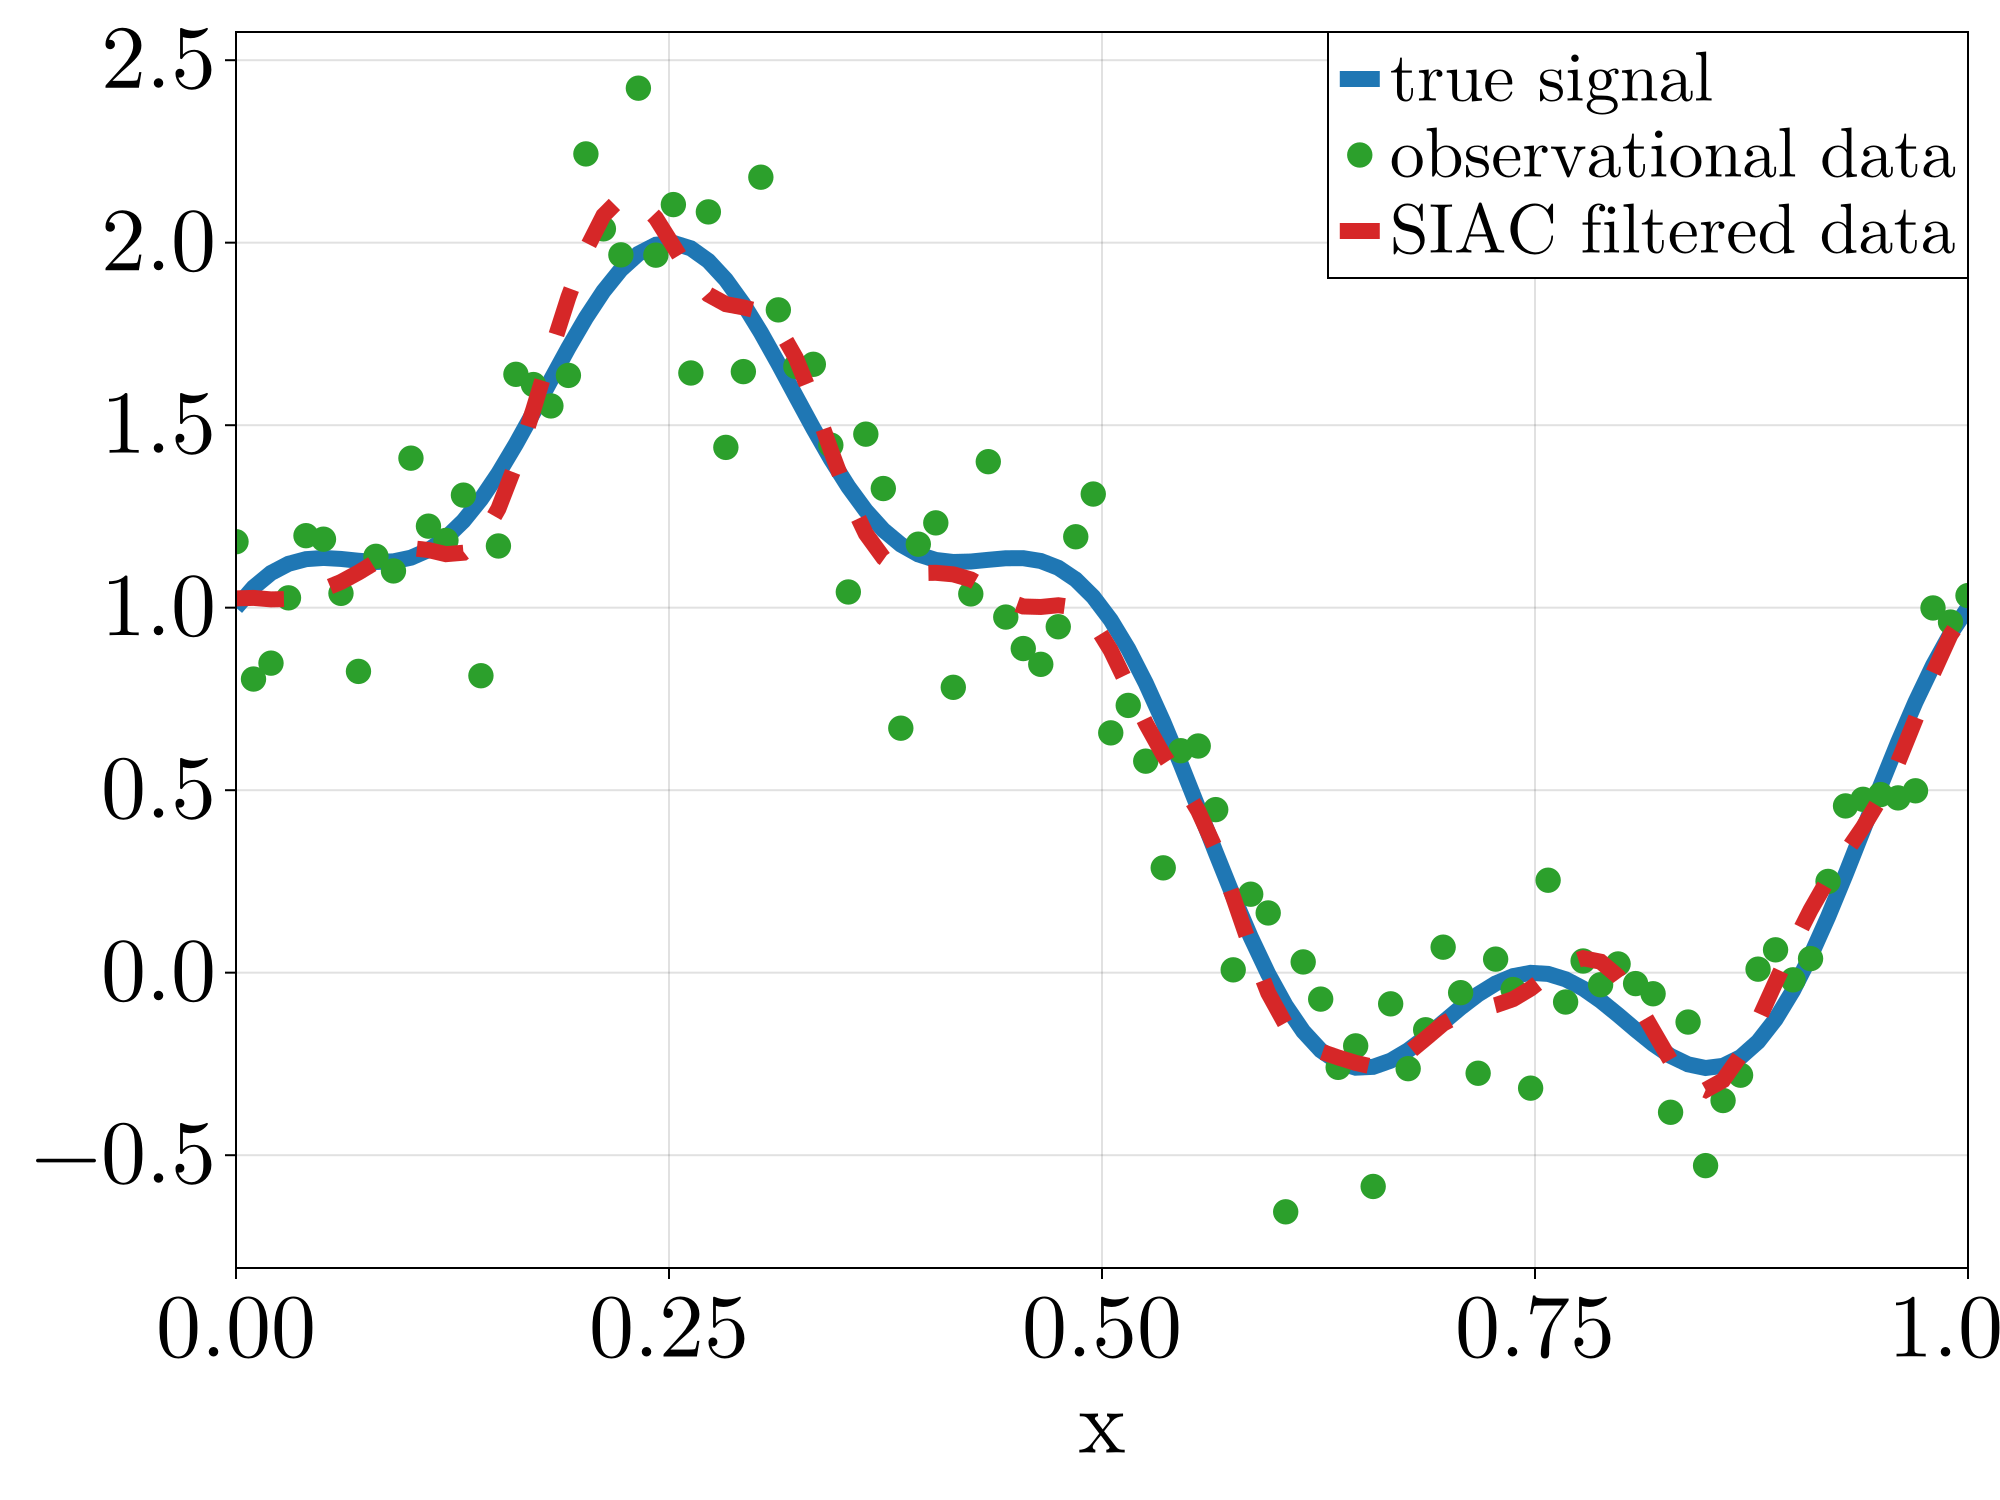

In [14]:
# Set default settings for the generated figures.
CairoMakie.set_theme!(CairoMakie.theme_latexfonts(), fontsize = 45)
pt_per_unit = 72.27/72
f = CairoMakie.Figure(size = (1000, 750))

pos = f[1, 1]
ax = CairoMakie.Axis(pos, limits = ((0,1), nothing), xticks = 0:0.25:1, yticks = -1:0.5:2.5, xlabel="x")
CairoMakie.lines!(pos, xx, fx, label="true signal", linewidth=8, color=palette(:tab10)[1])
CairoMakie.scatter!(pos, xx, fx_noisy, label="observational data", markersize=18, color=palette(:tab10)[3])
CairoMakie.lines!(pos, xx, fx_noisy_filter, label="SIAC filtered data", linewidth=8, linestyle=:dash, color=palette(:tab10)[4])

CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)

save(joinpath(results_dir, "signalDenoising_data.pdf"),f, pdf_version="1.5"; pt_per_unit)
CairoMakie.current_figure()

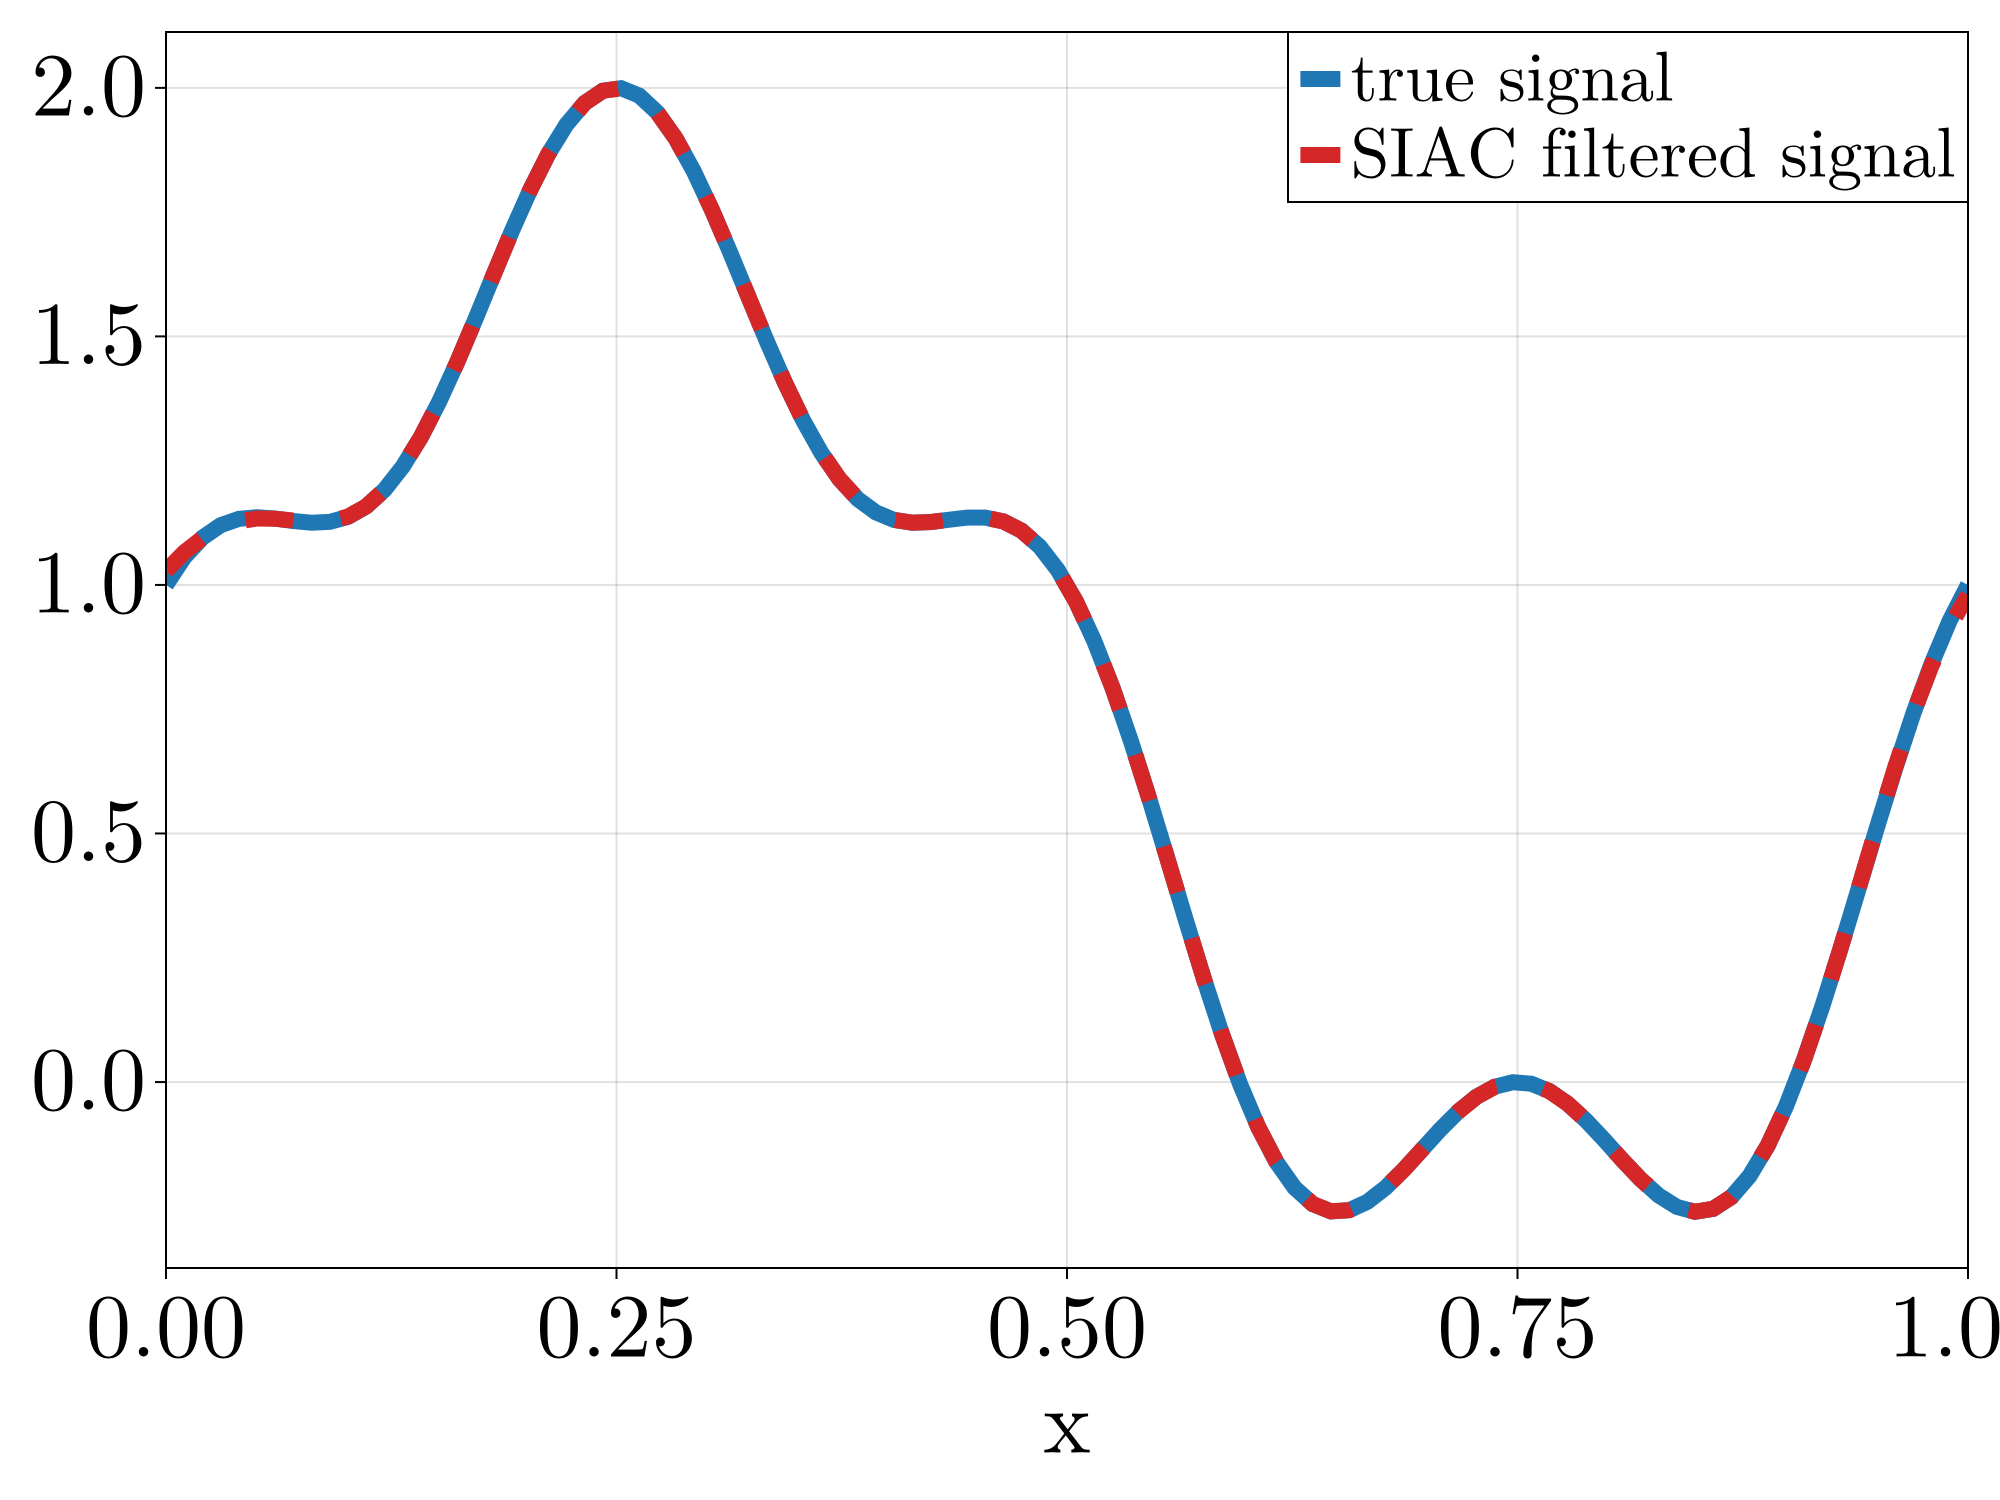

In [15]:
# Check SIAC filter applied on the underlying true function
# filtered data
fx_filter = Ffil*fx

# Set default settings for the generated figures.
CairoMakie.set_theme!(CairoMakie.theme_latexfonts(), fontsize = 45)
pt_per_unit = 72.27/72
f = CairoMakie.Figure(size = (1000, 750))

pos = f[1, 1]
ax = CairoMakie.Axis(pos, limits = ((0,1), nothing), xticks = 0:0.25:1, yticks = -1:0.5:2.5, xlabel="x")
CairoMakie.lines!(pos, xx, fx, label="true signal", linewidth=8, color=palette(:tab10)[1])
CairoMakie.lines!(pos, xx, fx_filter, label="SIAC filtered signal", linewidth=8, linestyle=:dash, color=palette(:tab10)[4])

CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)

save(joinpath(results_dir, "true_signal.png"),f, pdf_version="1.5"; pt_per_unit)
CairoMakie.current_figure()

# Statistical model setup

We consider the following model: 
\begin{align*}
    \mathbf{fx\_noisy} & \sim \mathcal{N}(F\mathbf{u},\sigma^2*I) = \mathcal{N}(F\mathbf{u},\alpha^{-1}*I), \\
    R \mathbf{u} & \sim \mathcal{N}(\mathbf{0},\beta^{-1}*I), \\ 
\end{align*}
where $R$ is the regularization operator. 
The associated posterior log PDF is 
$$            
                -\frac{\alpha}{2}  \| F\mathbf{u} - \mathbf{fx\_noisy} \|_2^2 
                -\frac{\beta}{2}  \| R\mathbf{u} \|_2^2 
                - d \alpha - d\beta + (\frac{N}{2}+c-1)\log \alpha + (\frac{N}{2}+c-1)\log \beta.
$$

In [16]:
# Set up the statistical model

# regularization operator
R = Matrix(1.0I, N, N) - Ffil

c = 1
d = 1.0e-3
# Define the posterior log-PDF for both unknown signal and hyperparameters  
function logpdf_posterior(u, α, β) 
    if α<=0 || β<=0
        logpdf = -Inf
    else
        logpdf = -(.5α)*norm(F*u-fx_noisy)^2 -(.5β)*norm(R*u)^2 - d*α - d*β + (N/2+c-1)*log(α) + (N/2+c-1)*log(β)
    end
        
    return logpdf
end

# Define the log-PDF by grouping all the parameters
logpdf(z) = logpdf_posterior(z[1:end-2], z[end-1], z[end])
# Define the negative log-PDF
neg_logpdf(z) = -logpdf(z)

neg_logpdf (generic function with 1 method)

# MAP estimate

We will compare the MAP estimates obtained from the built-in optimizer (limited-memory Broyden–Fletcher–Goldfarb–Shanno L-BFGS algorithm) and the Block Coordinate Descent (BCD) algorithm.

## L-BFGS

In [17]:
# Obtain MAP estimate using built-in optimizer L-BFGS

# Initial guess for the optimization (u, α and β)
initial_guess = vcat(zeros(N), 1.0, 1.0)

tLBFGS = @elapsed begin # execution time    
    # MAP estimation
    map_estimate = optimize(neg_logpdf, initial_guess, LBFGS())
end
    
# Extract the MAP estimate of u
fx_LBFGS_tmp = Optim.minimizer(map_estimate)
fx_LBFGS = fx_LBFGS_tmp[1:end-2]

100-element Vector{Float64}:
  0.9895403584706308
  1.0248388812719225
  1.0495904190162766
  1.065249240727669
  1.073132624202087
  1.0754331068040526
  1.0740226625545648
  1.0724102475516053
  1.073347618348963
  1.079504635783626
  1.095335582266368
  1.1220872441377672
  1.163384490039724
  ⋮
 -0.0816375804327577
  0.003563352246972344
  0.10072028621861137
  0.20697598103798204
  0.31734720116179105
  0.4279370906726414
  0.5356359216297721
  0.6369833069074623
  0.729864598881886
  0.8124992002717097
  0.8836238033557804
  0.9425117358590251

## BCD

In [18]:
# set up BCD function
using SparseArrays

function BCD_1d_scalar(F, y, R, c, d, QUIET)

    t_start = time()  # Measure time

    # Global constants and defaults
    MIN_ITER = 0
    MAX_ITER = 1000
    ABSTOL = 1e-8
    RELTOL = 1e-4

    # Data preprocessing
    m, n = size(F)  # number of (indirect) measurements and pixels
    k = size(R, 1)  # number of outputs of the regularization operator
    FtF = sparse(F' * F)  # product corresponding to the forward operator
    Fty = F' * y  # forward operator applied to the indirect data

    # Initial values for the inverse variances and the mean and others
    aalpha = 0.1
    bbeta = 1
    mu = zeros(n)
    mu_OLD = zeros(n)  # mean

    C_inv = Matrix(1.0I, n, n)

    abs_error = 0
    rel_error = 0

    if !QUIET
        println("iter\t abs error\t abs tol\t rel error\t rel tol")
    end

    # Iterate between the update steps until convergence or max number of iterations
    for counter in 1:MAX_ITER

        # 1) Fix aalpha, bbeta, and update x
        C_inv = sparse(aalpha * FtF + bbeta * R' * R)  # update covariance matrix
        mu = C_inv \ (aalpha * Fty)  # update the mean

        # 2) Fix x, B and update aalpha
        aalpha = (m + 2 * c) / (norm(F * mu - y)^2 + 2 * d)

        # 3) Fix x, aalpha and update B
        bbeta = (n + 2 * c) / (norm(R * mu)^2 + 2 * d)

        # Store certain values in history structure
        abs_error = norm(mu - mu_OLD)^2  # absolute error
        rel_error = (norm(mu - mu_OLD) / norm(mu_OLD))^2  # relative error

        mu_OLD = mu  # store value of mu

        if !QUIET
            println("$(counter)\t $(abs_error)\t $(ABSTOL)\t $(rel_error)\t $(RELTOL)")
        end

        # Check for convergence
        if abs_error < ABSTOL && rel_error < RELTOL && counter > MIN_ITER
            break
        end

    end

    # Output the time it took to perform all operations
    if !QUIET
        println("Elapsed time: ", time() - t_start, " seconds")
    end

    return mu, C_inv, aalpha, bbeta, Dict("abs_error" => abs_error, "rel_error" => rel_error)
end

BCD_1d_scalar (generic function with 1 method)

In [19]:
# Obtain MAP estimate using BCD algorithm
tBCD = @elapsed begin # execution time

    fx_BCD, C_inv, aalpha, bbeta, history = BCD_1d_scalar(F, fx_noisy, R, c, d, false ); 
    
end

iter	 abs error	 abs tol	 rel error	 rel tol
1	 108.01713463921439	 1.0e-8	 Inf	 0.0001
2	 0.1008690037317895	 1.0e-8	 0.0009338241017844048	 0.0001
3	 0.06835619187847876	 1.0e-8	 0.0006342583531604239	 0.0001
4	 0.0034393450745194777	 1.0e-8	 3.195162123893369e-5	 0.0001
5	 4.167835194995376e-6	 1.0e-8	 3.872637419880407e-8	 0.0001
6	 2.8338743040373114e-9	 1.0e-8	 2.6331747122296513e-11	 0.0001
Elapsed time: 0.08999991416931152 seconds


2.8403807

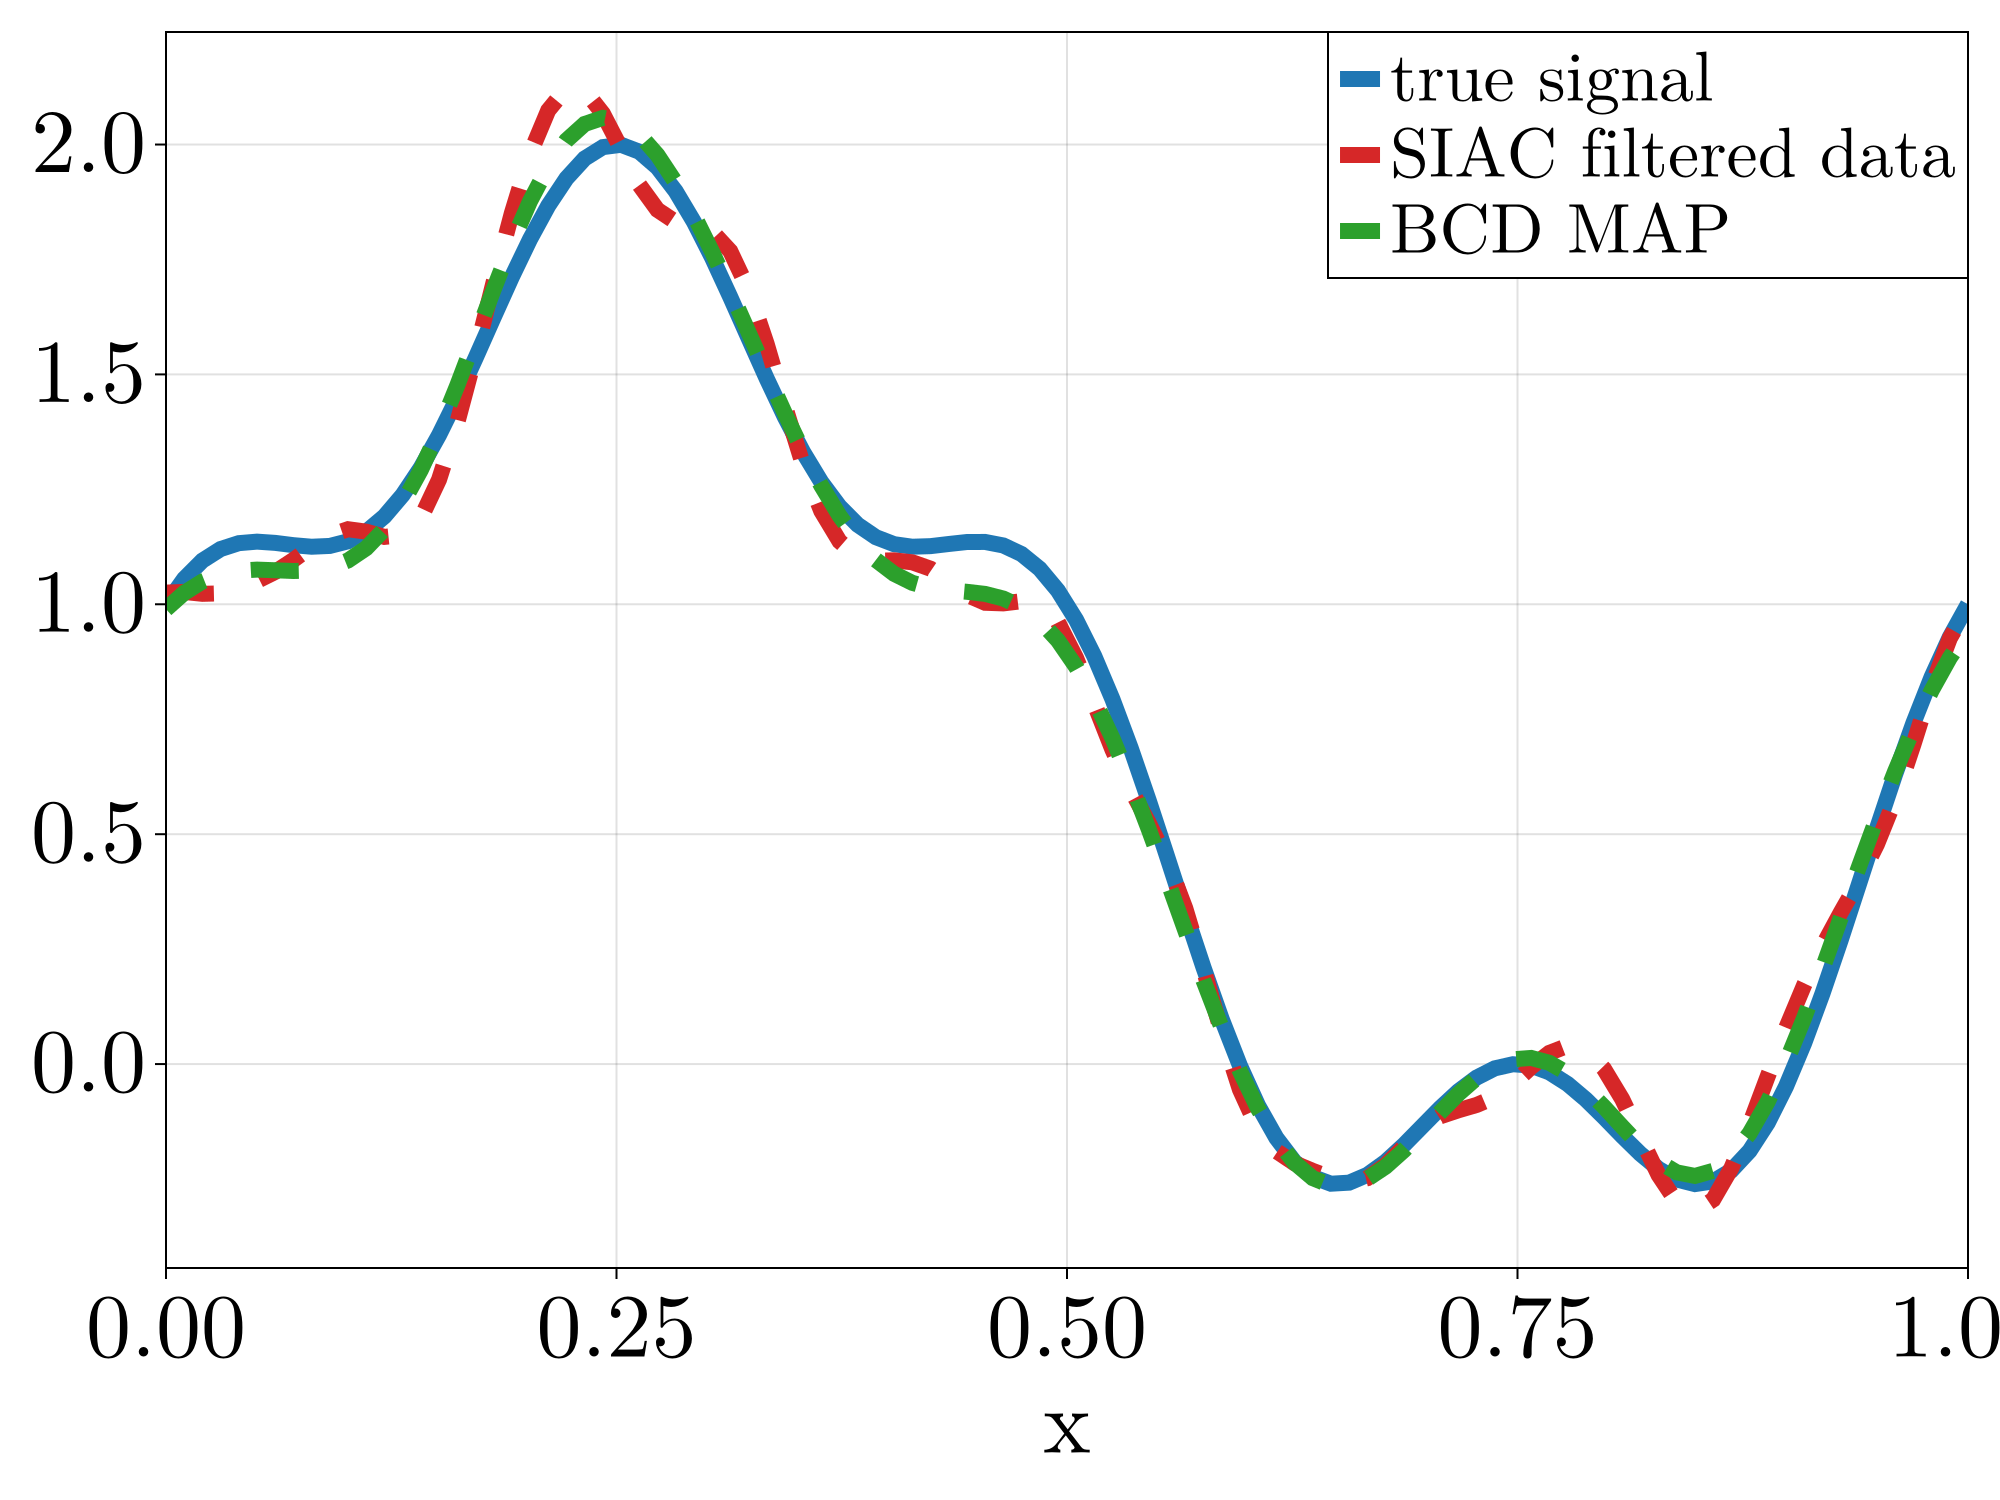

In [20]:
CairoMakie.set_theme!(CairoMakie.theme_latexfonts(), fontsize = 45)
pt_per_unit = 72.27/72


f1 = CairoMakie.Figure(size = (1000, 750))

pos = f1[1, 1]
ax = CairoMakie.Axis(pos, limits = ((0,1), nothing), xticks = 0:0.25:1, yticks = -1:0.5:2.5, xlabel="x")
CairoMakie.lines!(pos, xx, fx, label="true signal", linewidth=8, color=palette(:tab10)[1])
CairoMakie.lines!(pos, xx, fx_noisy_filter, label="SIAC filtered data", linewidth=8, linestyle=:dash, color=palette(:tab10)[4])
CairoMakie.lines!(pos, xx, fx_LBFGS, label="L-BFGS MAP", linewidth=8, linestyle=:dash, color=palette(:tab10)[3])

CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)

save(joinpath(results_dir, "MAP_LBFGS.pdf"),f1, pdf_version="1.5"; pt_per_unit)

f2 = CairoMakie.Figure(size = (1000, 750))

pos = f2[1, 1]
ax = CairoMakie.Axis(pos, limits = ((0,1), nothing), xticks = 0:0.25:1, yticks = -1:0.5:2.5, xlabel="x")
CairoMakie.lines!(pos, xx, fx, label="true signal", linewidth=8, color=palette(:tab10)[1])
CairoMakie.lines!(pos, xx, fx_noisy_filter, label="SIAC filtered data", linewidth=8, linestyle=:dash, color=palette(:tab10)[4])
CairoMakie.lines!(pos, xx, fx_LBFGS, label="BCD MAP", linewidth=8, linestyle=:dash, color=palette(:tab10)[3])

CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)

save(joinpath(results_dir, "MAP_BCD.pdf"),f2, pdf_version="1.5"; pt_per_unit)
CairoMakie.current_figure()

In [21]:
# Compare the execution times for MAP estimates
println(@sprintf("Time for MAP estimate with LBFGS: %-15.4f seconds", tLBFGS))
println(@sprintf("Time for MAP estimate with BCD:   %-15.4f seconds", tBCD))

# Compute relative L2 errors
rel_l2_err_LBFGS = norm(fx_LBFGS - fx) / norm(fx)
rel_l2_err_BCD = norm(fx_BCD - fx) / norm(fx)

# Compare relative L2 errors
println(@sprintf("Relative l2 error for MAP estimate with LBFGS: %-15.4e", rel_l2_err_LBFGS))
println(@sprintf("Relative l2 error for MAP estimate with BCD:   %-15.4e", rel_l2_err_BCD))


Time for MAP estimate with LBFGS: 6.0347          seconds
Time for MAP estimate with BCD:   2.8404          seconds
Relative l2 error for MAP estimate with LBFGS: 4.8460e-02     
Relative l2 error for MAP estimate with BCD:   4.8457e-02     


# Sampling

We will compare the performance of Gibbs sampling and AM sampling. Here we do AM sampling.

## Generate random initializations

In [22]:
## Genrate random samples from the original prior 

# Set-up an array for the initializations 
initial_random = Array{Float64}(undef, N+2, nr_chains)

# Generate α- and β-samples from the gamma distribution
α_random = rand(Gamma(c, 1/d), nr_chains)
β_random = rand(Gamma(c, 1/d), nr_chains)

# Get corresponding u-sample by performing an x-update 
u_random = Array{Float64}(undef, N, nr_chains)
for j in 1:nr_chains
    α = α_random[j]
    β = β_random[j]
    C_inv = sparse(α*F'*F + β*R'*R)  # update covariance matrix
    u_random[:,j] = C_inv \ (α*F'*fx_noisy)  # update the mean
end

# Collect the α-, β-, and u-samples
for j in 1:nr_chains
    initial_random[1:end-2,j] .= u_random[:,j]
    initial_random[end-1,j] = α_random[j]
    initial_random[end,j] = β_random[j]
end

In [23]:
# Initialization option: "MAP", "random"
init = "random" 

# Choose an initialization for the MCMC chains 
init_param = Array{Float64}(undef, N+2, nr_chains)

# Use MAP estimate 
if init=="MAP"
    # Select the initial set of parameters 
    for j in 1:nr_chains 
        init_param[:,j] = fx_MAP_tmp
    end

# Use random initializations 
elseif init=="random"
    init_param = initial_random

# Throw an error if none of the available options is provided
else
    error("Invalid initialization option provided: $init. Please choose either 'MAP' or 'random'.")
end

102×4 Matrix{Float64}:
    0.984005    1.09664      1.10148      1.15873
    1.02001     0.914666     0.90815      0.832479
    1.04646     0.935891     0.930583     0.870039
    1.0645      1.01832      1.01876      1.02463
    1.075       1.10329      1.10879      1.17331
    1.07979     1.10827      1.11295      1.16755
    1.07992     1.04753      1.04701      1.04136
    1.07906     0.964177     0.95599      0.860842
    1.07957     1.13545      1.13545      1.13828
    1.08387     1.1421       1.13991      1.11203
    1.0972      1.29648      1.30312      1.38049
    1.12059     1.21222      1.21332      1.22186
    1.15885     1.18468      1.18489      1.18507
    ⋮                                  
    0.104509    0.108932     0.105014     0.0569883
    0.212189    0.254048     0.253989     0.251585
    0.322994    0.39131      0.395109     0.440058
    0.432926    0.435288     0.43741      0.464405
    0.539259    0.48604      0.485803     0.486551
    0.638543    0.532967    

## AM Sampling

In [24]:
# https://mvihola.github.io/docs/AdaptiveMCMC.jl
# Prepare arguments. 
# nr_chains = 4 # number of chains to sample 
nr_samples_raw = 10^5 # number of samples 
# thin = 10^1 # Thinning factor; only every thin:th sample is stored 
thin = 1 # Thinning factor; only every thin:th sample is stored 
burn_in_raw = Int64(ceil(nr_samples_raw/10)) # Burn-in length of 10%
# burn_in_raw = 0

# number of (burn-in) samples after thinning 
# nr_samples = Int64( nr_samples_raw/thin )
nr_samples = Int64( nr_samples_raw/thin )
burn_in = Int64(ceil(nr_samples/10)) # Burn-in length of 10%
# burn_in = 0

# number of parameters 
nr_params_AM = N+2 

102

In [25]:
# using Pkg
# Produce samples from the target distribution.
# Note: Looking at the acceptance rate, :asm seems to work the best

# Initialize
AM_chn_values = zeros(Float64, nr_samples-burn_in, nr_params_AM, nr_chains)

# Start the wall clock timer
wall_start = now()
t_start = time()

j=1
# Use multiple threads. 
@showprogress Threads.@threads for j in 1:nr_chains 
    # generate samples
    AM_chn_values[:,:,j] = adaptive_rwm(
        init_param[:,j], 
        logpdf, 
        nr_samples_raw; # raw number of samples  
        algorithm=:asm, 
        b=burn_in_raw+1, # burn in length 
        # thin=thin, # Thinning factor
        progress=true # show progress meter
    ).X'
    
    # Clear memory after each chain
    GC.gc()
end

# End the wall clock timer
wall_end = now()
wall_duration_ms = wall_end - wall_start
t_time = time() - t_start
# Convert wall duration to seconds
AM_wall_duration = Dates.value(wall_duration_ms) / 1000

# Interleave θ and z names
param_names = Vector{String}(undef, nr_params_AM)
param_names[1:N] .= [string("u[", i, "]") for i in 1:N ]
param_names[end-1] = "α"
param_names[end] = "β"

# Create the Chains object
AM_chn = Chains(AM_chn_values, Symbol.(param_names));

# Free the memory occupied by chn_values
AM_chn_values = nothing
GC.gc()  # Optionally trigger garbage collection manually

# Display the results
println("AM sampling completed.")
print(t_time)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03m
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


AM sampling completed.
11.594000101089478

In [26]:
# Initialize an array to store acceptance rates for each chain
acceptance_rates = zeros(nr_chains) 

# Compute the acceptance rate for each chain
Threads.@threads for j in 1:nr_chains
    accepted = 0
    for i in 2:size(AM_chn.value, 1)
        # Compare z parameters between successive iterations
        if any(AM_chn.value[i, :, j] .!= AM_chn.value[i-1, :, j])
            accepted += 1
        end
    end
    acceptance_rate = accepted / (nr_samples - 1)
    acceptance_rates[j] = acceptance_rate
end

# Compute the average acceptance rate
average_acceptance_rate = mean(acceptance_rates)

# Print acceptance rates for each chain
for (j, rate) in enumerate(acceptance_rates)
    println("Chain $j acceptance rate: $rate")
end
println("Average acceptance rate: $average_acceptance_rate")

Chain 1 acceptance rate: 0.2105021050210502
Chain 2 acceptance rate: 0.21255212552125521
Chain 3 acceptance rate: 0.2105921059210592
Chain 4 acceptance rate: 0.2103121031210312
Average acceptance rate: 0.21098960989609897


### Traces for a specific location

We focus on investigating  $(u[j],\alpha,\beta)$ for $j=50$.
Note that $t[j] \approx 0.5$ and $u_{\rm true}[j] \approx 0.52$ for $j=50$.

In [27]:
# Extract sample values 
j = 50 

# Get the u-samples
AM_u_j = get(AM_chn, :u).u[j]
# Get the α-samples
AM_α = get(AM_chn, :α).α
# Get the β-samples
AM_β = get(AM_chn, :β).β

2-dimensional AxisArray{Float64,2,...} with axes:
    :iter, 1:1:90000
    :chain, 1:4
And data, a 90000×4 Matrix{Float64}:
 3584.63  205.098  1143.73  251.12
 3584.63  205.098  1143.73  251.12
 3584.63  205.098  1143.73  251.12
 3584.63  205.112  1143.73  251.115
 3584.63  205.116  1143.72  251.115
 3584.63  205.111  1143.71  251.115
 3584.63  205.111  1143.71  251.115
 3584.63  205.111  1143.71  251.115
 3584.64  205.111  1143.71  251.115
 3584.64  205.096  1143.71  251.115
 3584.64  205.103  1143.71  251.119
 3584.63  205.103  1143.71  251.119
 3584.63  205.103  1143.71  251.119
    ⋮                       
 3586.21  203.345  1143.03  250.572
 3586.21  203.345  1143.03  250.579
 3586.21  203.345  1143.03  250.579
 3586.21  203.35   1143.03  250.579
 3586.21  203.35   1143.03  250.579
 3586.2   203.35   1143.03  250.575
 3586.2   203.355  1143.03  250.575
 3586.2   203.336  1143.03  250.575
 3586.21  203.336  1143.03  250.575
 3586.21  203.336  1143.04  250.575
 3586.2   203.336  114

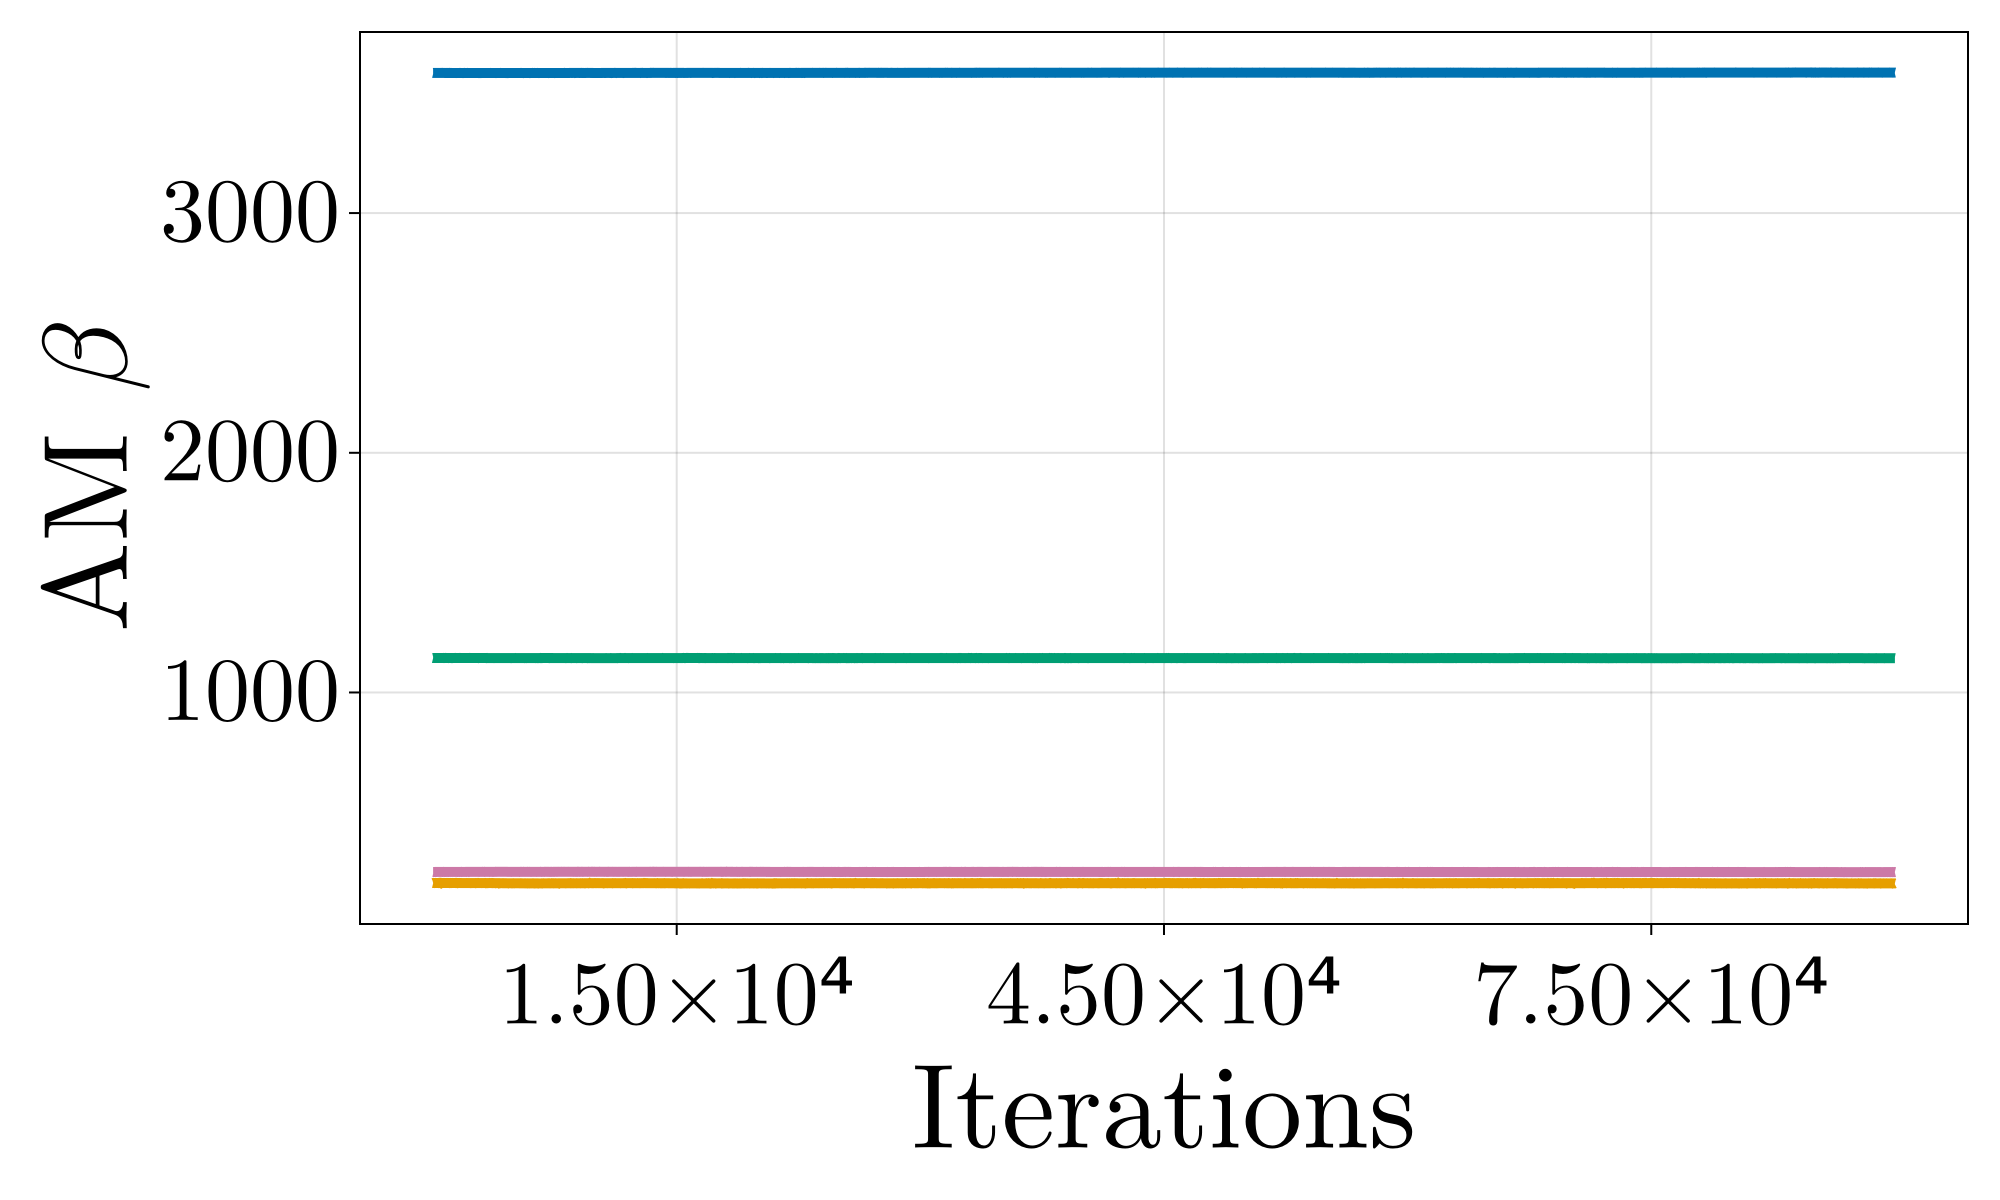

In [28]:
# Set default settings for the generated figures.
CairoMakie.set_theme!(CairoMakie.theme_latexfonts(), fontsize = 60)
pt_per_unit = 72.27/72


# Trace Plot u_j
f = CairoMakie.Figure(size = (1000, 600))
pos = f[1, 1]
ax = CairoMakie.Axis(pos, xticks=[1.5e4; 4.5e4; 7.5e4], xlabel="Iterations", ylabel=L"AM $u_{50}$", xticklabelsize=45,  yticklabelsize=45)
CairoMakie.lines!(pos, AM_u_j[:,1], linewidth=2)
CairoMakie.lines!(pos, AM_u_j[:,2], linewidth=2)
CairoMakie.lines!(pos, AM_u_j[:,3], linewidth=2)
CairoMakie.lines!(pos, AM_u_j[:,4], linewidth=2)

# CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)
save(joinpath(results_dir, "chain_AM_u50.pdf"),f, pdf_version="1.5"; pt_per_unit)

# Trace Plot α
f = CairoMakie.Figure(size = (1000, 600))
pos = f[1, 1]
ax = CairoMakie.Axis(pos, xticks=[1.5e4; 4.5e4; 7.5e4], xlabel="Iterations", ylabel=L"AM $\alpha$", xticklabelsize=45,  yticklabelsize=45)
CairoMakie.lines!(pos, AM_α[:,1], linewidth=5)
CairoMakie.lines!(pos, AM_α[:,2], linewidth=5)
CairoMakie.lines!(pos, AM_α[:,3], linewidth=5)
CairoMakie.lines!(pos, AM_α[:,4], linewidth=5)

# CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)
save( joinpath(results_dir, "chain_AM_alpha.png"),f, pdf_version="1.5"; pt_per_unit)

# Trace Plot β
f = CairoMakie.Figure(size = (1000, 600))
pos = f[1, 1]
ax = CairoMakie.Axis(pos, xticks=[1.5e4; 4.5e4; 7.5e4], xlabel="Iterations", ylabel=L"AM $\beta$", xticklabelsize=45,  yticklabelsize=45)
CairoMakie.lines!(pos, AM_β[:,1], linewidth=5)
CairoMakie.lines!(pos, AM_β[:,2], linewidth=5)
CairoMakie.lines!(pos, AM_β[:,3], linewidth=5)
CairoMakie.lines!(pos, AM_β[:,4], linewidth=5)

# CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)
save( joinpath(results_dir, "chain_AM_beta.png"),f, pdf_version="1.5"; pt_per_unit)
CairoMakie.current_figure()

In [29]:
AM_u_j

2-dimensional AxisArray{Float64,2,...} with axes:
    :iter, 1:1:90000
    :chain, 1:4
And data, a 90000×4 Matrix{Float64}:
 0.857696  1.13135  1.1399   1.26293
 0.857696  1.13135  1.1399   1.26293
 0.857696  1.13135  1.1399   1.26293
 0.857696  1.1134   1.1399   1.25575
 0.857696  1.09639  1.14125  1.25575
 0.857696  1.09744  1.13467  1.25575
 0.861961  1.09744  1.13467  1.25301
 0.863102  1.09744  1.13467  1.25301
 0.863732  1.09744  1.13467  1.25301
 0.863732  1.11127  1.13467  1.25301
 0.863732  1.1225   1.13467  1.25395
 0.863939  1.1225   1.13467  1.25395
 0.863939  1.1225   1.13205  1.25395
 ⋮                           
 1.19552   1.16254  1.13962  1.26597
 1.19552   1.16254  1.13962  1.27155
 1.19552   1.16254  1.13962  1.27155
 1.19474   1.16207  1.13962  1.27155
 1.20098   1.16207  1.13962  1.27155
 1.20235   1.16207  1.13962  1.26943
 1.20235   1.15737  1.13962  1.26943
 1.20235   1.13427  1.13962  1.26943
 1.20337   1.13427  1.13962  1.26943
 1.20337   1.13427  1.1427   1.2

### Multivariate potential scale reduction factor (MPSRF)

In [30]:
# Compute the MPSRF versus number of samples 
num_points = 10  # Number of equidistant points
nr_aux = length(AM_chn[:, 1, 1])
increments = Int.( ceil.( maprange(log, 10^3, nr_aux, length=num_points) ))
# maprange function in pkg FlexiMaps

# Array to store MPSRF values
AM_MPSRF_values = Float64[]

# Compute MPSRF for each subset of the chain
@showprogress for n in increments 
    AM_MPSRF = gelmandiag_multivariate(AM_chn[1:n, :, :] )
    push!(AM_MPSRF_values, AM_MPSRF[2])
end

# Generate figure
Plots.pyplot()

# Set tick locations and labels
xticks = [10^1, 10^2, 10^3, 10^4, 10^5, 10^6]
yticks = [10^(-3), 10^(-2), 10^(-1), 10^(0), 10^(1), 10^(2)]

# Create the plot 
plot_AM_MPSRF = plot(increments, AM_MPSRF_values.-1; 
    lw=4, ls=:solid, color = :red )

# Make some cosmetic changes to the plot 
plot!( plot_AM_MPSRF, 
    xscale=:log10, yscale=:log10, # log scale for x-axis and labels
    xlabel="number of samples", ylabel="MPSRF-1", # labels 
    tickfontsize=14, labelfontsize=14, legend=false,
    # xticks=xticks, yticks=yticks
)

# Display the plot
display(plot_AM_MPSRF)
# Save the plot
savefig(plot_AM_MPSRF, joinpath(results_dir, "MPSRF_AM.png"))  # Save as PNG

println("The last value of the MPSRF is")
print(AM_MPSRF_values[end])

Progress: 100%|█████████████████████████████████████████| Time: 0:00:11
[ Info: Installing matplotlib via the Conda matplotlib package...
[ Info: Running `conda install -y matplotlib` in root environment


Channels:
 - conda-forge
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\rstuh\.julia\conda\3\x86_64

  added / updated specs:
    - matplotlib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          51 KB  conda-forge
    brotli-1.2.0               |       h2d644bc_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       hfd05255_1          22 KB  conda-forge
    cairo-1.18.4               |       h477c42c_1         1.5 MB  conda-forge
    contourpy-1.3.3            |  py313h1a38498_4         240 KB  conda-forge
    cycler-0.12.1              |     pyhcf101f3_2          14 KB  conda-forge
    double-conversion-3.4.0    |       hac47afa_0          69 KB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |  

LoadError: UndefVarError: `plot` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in PyPlot.
Hint: a global variable of this name also exists in GR.jlgr.
    - Also exported by GR.
Hint: a global variable of this name also exists in RecipesBase.
    - Also exported by Plots.
    - Also exported by StatsPlots.
Hint: a global variable of this name also exists in Makie.
    - Also exported by CairoMakie.

In [ ]:
display(AM_MPSRF_values)

10-element Vector{Float64}:
 1.1503870681633477e9
 5.934659772234501e8
 3.1848559592476773e8
 1.5851565535958663e8
 5.3336630105210625e7
 1.8128014737143494e7
 2.35269799227715e6
 2.286849770091324e6
 2.585602598134851e6
 1.616330894342197e6

### Effective sample size (ESS)

In [ ]:
AM_ESS = ess(AM_chn)

# Assuming ESS_original is a DataFrame or similar structure
AM_ess_values = AM_ESS[:,2]  # Extract the 'ess' column

# Compute the minimum, maximum, mean, and median
@show AM_min_ess = minimum(AM_ess_values)
@show AM_max_ess = maximum(AM_ess_values)
@show AM_mean_ess = mean(AM_ess_values)
@show AM_median_ess = median(AM_ess_values)

# Wall duration to generate samples
@show AM_wall_duration

# Compute the minimum, maximum, mean, and median per second 
@show AM_min_ess_perSec = AM_min_ess/AM_wall_duration
@show AM_max_ess_perSec = AM_max_ess/AM_wall_duration
@show AM_mean_ess_perSec = AM_mean_ess/AM_wall_duration
@show AM_median_ess_perSec = AM_median_ess/AM_wall_duration

AM_min_ess = minimum(AM_ess_values) = 721.496240413161
AM_max_ess = maximum(AM_ess_values) = 972.7710049931874
AM_mean_ess = mean(AM_ess_values) = 851.0803050510734
AM_median_ess = median(AM_ess_values) = 847.872724379954
AM_wall_duration = 21.013
AM_min_ess_perSec = AM_min_ess / AM_wall_duration = 34.33570839067058
AM_max_ess_perSec = AM_max_ess / AM_wall_duration = 46.293770760633286
AM_mean_ess_perSec = AM_mean_ess / AM_wall_duration = 40.50256056018053
AM_median_ess_perSec = AM_median_ess / AM_wall_duration = 40.34991311949526


40.34991311949526

In [ ]:
# Illustrate the mean and variance of u 

# Extract the samples of u
AM_u_samples = get(AM_chn, :u).u

# Compute the pointwise mean and variance of the samples
AM_u_mean = [mean(AM_u_samples[i]) for i in 1:N]
AM_u_lower_quantile = [quantile(vec(AM_u_samples[i]), 0.05) for i in 1:N]  # 5% quantile
AM_u_upper_quantile = [quantile(vec(AM_u_samples[i]), 0.95 ) for i in 1:N]  # 95% quantile

# Convert to vectors for plotting
AM_u_lower_quantile = collect(AM_u_lower_quantile)
AM_u_upper_quantile = collect(AM_u_upper_quantile)

pyplot() 
# Create the plot for the underlying true function
plot_AM_var = Plots.plot( 
    xx, fx; 
    label="true signal", lw=3, ls=:solid 
)
# Add AM mean
Plots.plot!(plot_AM_var, 
    xx, AM_u_mean;
    label=L"\text{AM mean}",
    lw=3, ls=:dash, lc=:green
)
# Add AM quantile
Plots.plot!(plot_AM_var, 
    xx, AM_u_lower_quantile; 
    label="5% Quantile", lw=1, ls=:dash, color=:lightgreen
)
# Add AM quantile
Plots.plot!(plot_AM_var, 
    xx, AM_u_upper_quantile; 
    label="95% Quantile", lw=1, ls=:dash, color=:lightgreen
)
# Add shaded region between the quantiles for x
Plots.plot!(plot_AM_var,
    xx, AM_u_lower_quantile, fillrange = AM_u_upper_quantile, 
    label=false, fillalpha = 0.3, lw=0, color=:lightgreen
)
# Make some cosmetic changes to the plot 
Plots.plot!(plot_AM_var,
    xlabel=L"x",  
    tickfontsize=12, labelfontsize=12, legendfontsize=10 # font sizes 
)
# Display the plot
display(plot_AM_var)
# Save the plot
savefig(plot_AM_var, joinpath(results_dir, "quantile_AM.png"))  # Save as PNG

LoadError: ArgumentError: Package PyPlot not found in current path.
- Run `import Pkg; Pkg.add("PyPlot")` to install the PyPlot package.

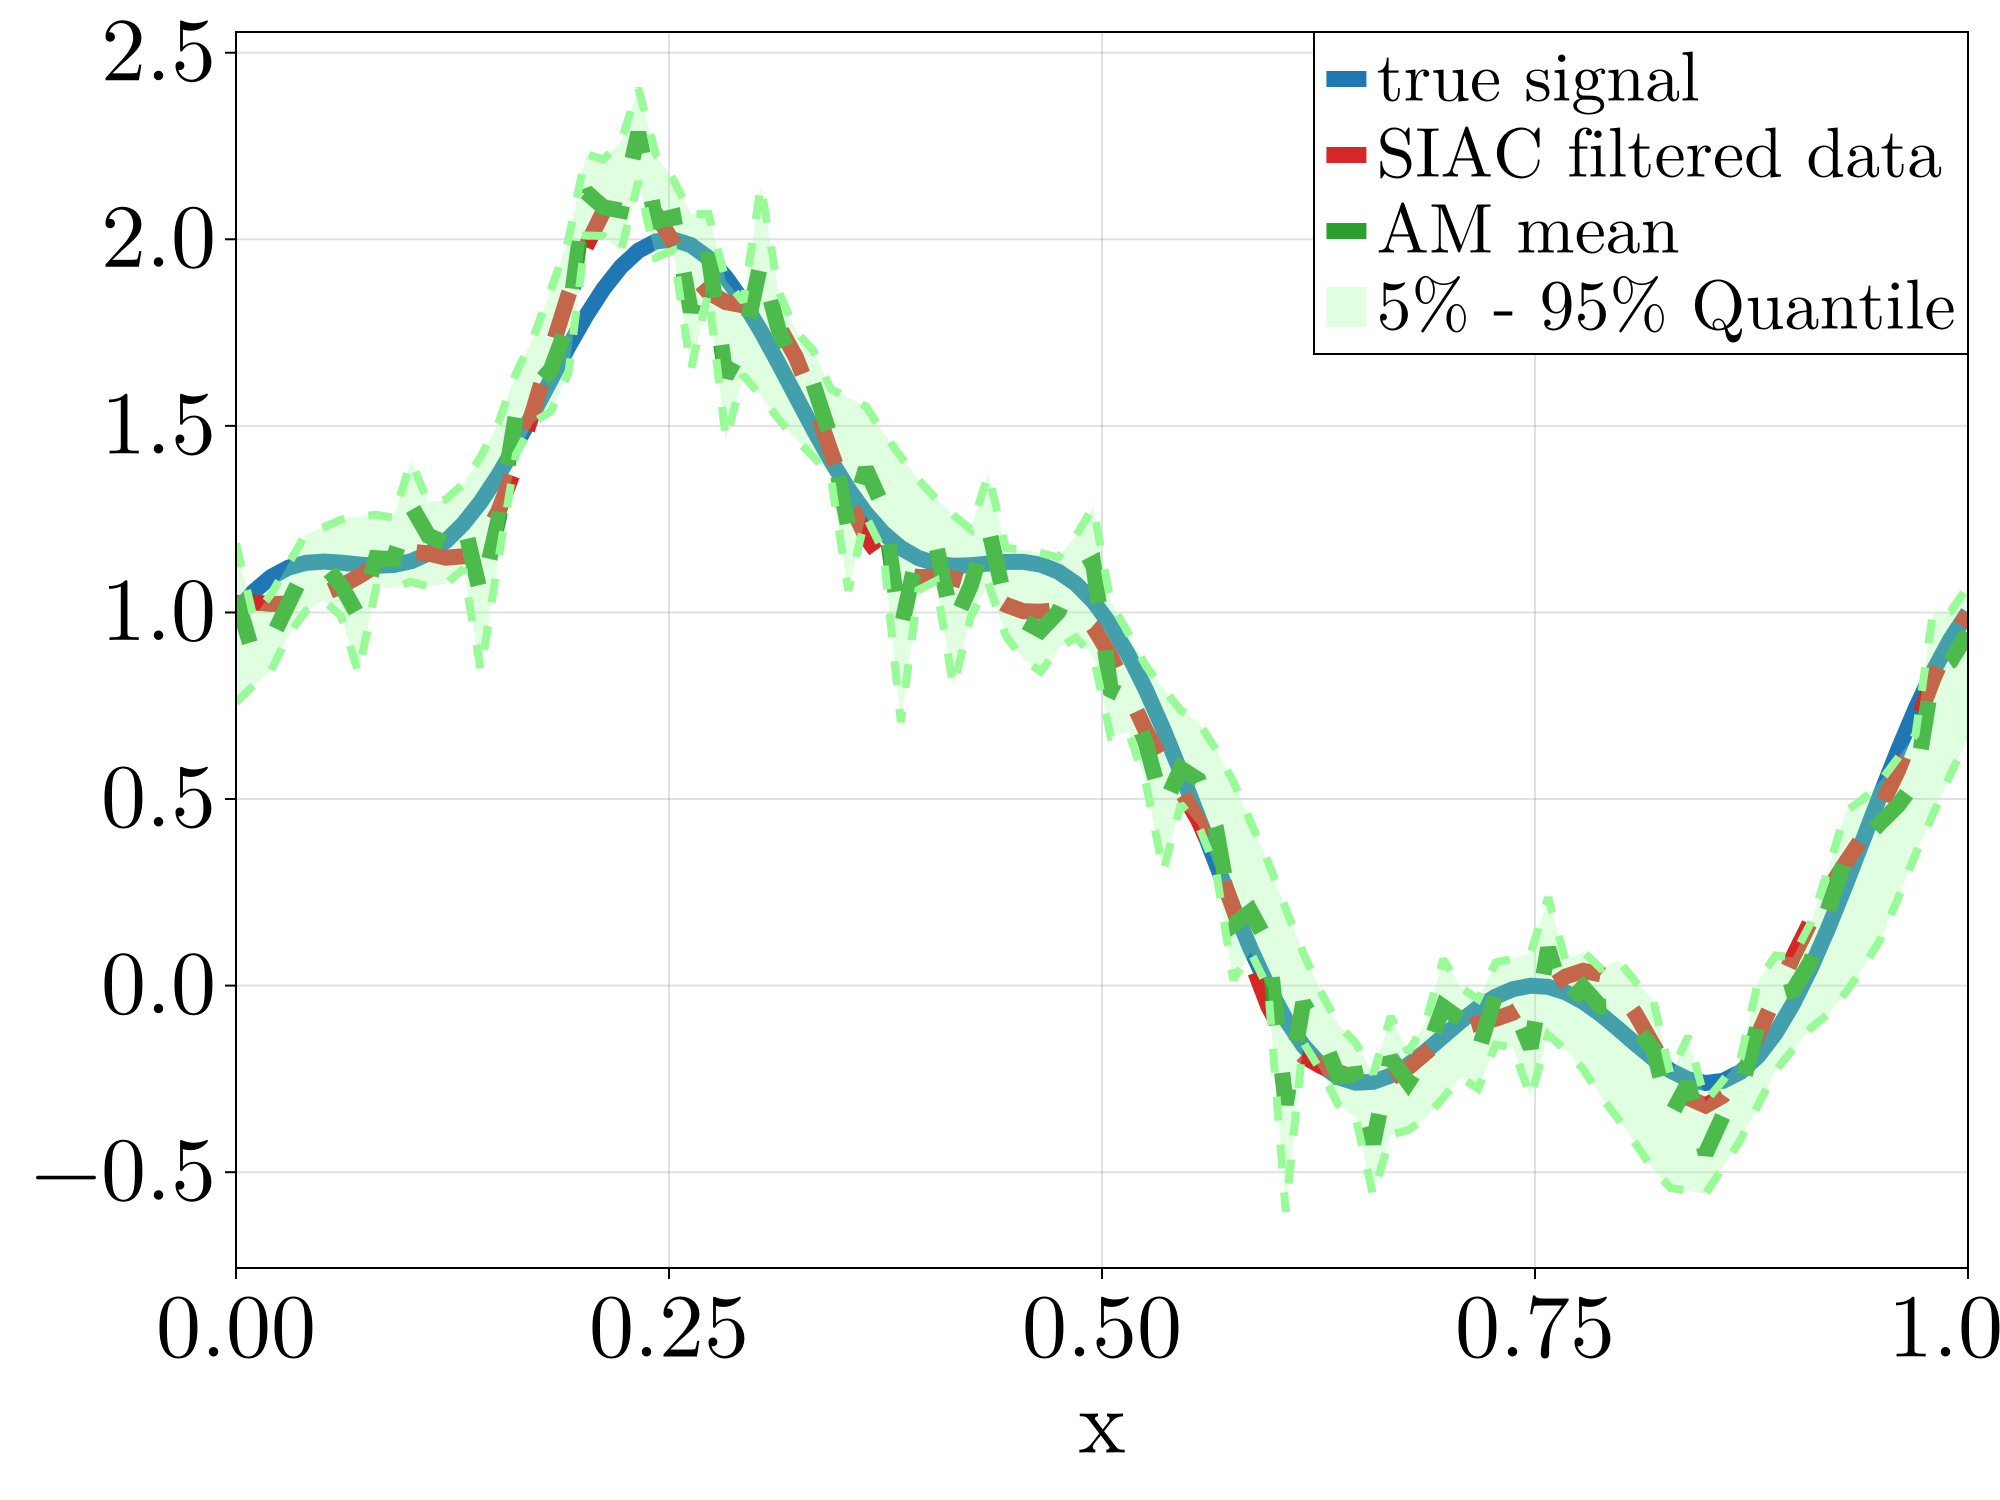

In [ ]:
# Set default settings for the generated figures.
CairoMakie.set_theme!(CairoMakie.theme_latexfonts(), fontsize = 45)
pt_per_unit = 72.27/72
f = CairoMakie.Figure(size = (1000, 750))

pos = f[1, 1]
ax = CairoMakie.Axis(pos, limits = ((0,1), nothing), xticks = 0:0.25:1, yticks = -1:0.5:2.5, xlabel="x")
CairoMakie.lines!(pos, xx, fx, label="true signal", linewidth=8, color=palette(:tab10)[1])
CairoMakie.lines!(pos, xx, fx_noisy_filter, label="SIAC filtered data", linewidth=8, linestyle=:dash, color=palette(:tab10)[4])
CairoMakie.lines!(pos, xx, AM_u_mean, label="AM mean", linewidth=8, linestyle=:dash, color=palette(:tab10)[3])
CairoMakie.lines!(pos, xx, AM_u_lower_quantile, linewidth=4, linestyle=:dash, color=:palegreen)
CairoMakie.lines!(pos, xx, AM_u_upper_quantile, linewidth=4, linestyle=:dash, color=:palegreen)
CairoMakie.band!(pos, xx, min.(AM_u_lower_quantile,AM_u_upper_quantile), max.(AM_u_lower_quantile,AM_u_upper_quantile), label="5% - 95% Quantile range", color=:palegreen, alpha=0.3)

CairoMakie.Legend(pos, ax, tellheight = false, tellwidth = false, valign = :top, halign = :right, orientation = :vertical, labelsize=35)
CairoMakie.linkaxes!(filter(y -> y isa Axis, f.content)...)

save(joinpath(results_dir, "plot_add_AM.png"),f, pdf_version="1.5"; pt_per_unit)
CairoMakie.current_figure()